<a href="https://colab.research.google.com/github/Utsav-exe/HAR-Machine-Learning/blob/main/Final_HAR_Showdown.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

# Ensure we are in the /content directory before attempting to remove/clone
%cd /content

# Clean up previous runs if any
if os.path.exists('HAR-Machine-Learning'):
    !rm -rf HAR-Machine-Learning
if os.path.exists('UCI HAR Dataset.zip'):
    !rm "UCI HAR Dataset.zip"

!git clone https://github.com/Utsav-exe/HAR-Machine-Learning.git
%cd HAR-Machine-Learning
!wget "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
!unzip -q "UCI HAR Dataset.zip"

/content
Cloning into 'HAR-Machine-Learning'...
remote: Enumerating objects: 30, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 30 (delta 10), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (30/30), 214.68 KiB | 7.16 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/HAR-Machine-Learning
--2026-04-07 19:32:32--  https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘UCI HAR Dataset.zip’

UCI HAR Dataset.zip     [    <=>             ]  58.17M  76.7MB/s    in 0.8s    

2026-04-07 19:32:33 (76.7 MB/s) - ‘UCI HAR Dataset.zip’ saved [60999314]



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
activity_labels = pd.read_csv('UCI HAR Dataset/activity_labels.txt', sep='\s+', header=None, names=['ID', 'Activity'])
features = pd.read_csv('UCI HAR Dataset/features.txt', sep='\s+', header=None, names=['ID', 'Sensor_Feature'])

print("Activity Map:")
print(activity_labels)
print(f"\nTotal Features found: {len(features)}")

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_30449/2457569251.py:5: SyntaxWarning: invalid escape sequence '\s'
  activity_labels = pd.read_csv('UCI HAR Dataset/activity_labels.txt', sep='\s+', header=None, names=['ID', 'Activity'])
/tmp/ipykernel_30449/2457569251.py:6: SyntaxWarning: invalid escape sequence '\s'
  features = pd.read_csv('UCI HAR Dataset/features.txt', sep='\s+', header=None, names=['ID', 'Sensor_Feature'])


Activity Map:
   ID            Activity
0   1             WALKING
1   2    WALKING_UPSTAIRS
2   3  WALKING_DOWNSTAIRS
3   4             SITTING
4   5            STANDING
5   6              LAYING

Total Features found: 561


In [3]:
X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None)#sensor data
y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt', sep='\s+', header=None)#activity id
X_train.columns = features['Sensor_Feature']#assigning 561 features as columns in x_train
X_train['Activity_ID'] = y_train[0]#which row belongs to which activity

print(f"Data Loaded! Shape: {X_train.shape}")

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_30449/3326702203.py:1: SyntaxWarning: invalid escape sequence '\s'
  X_train = pd.read_csv('UCI HAR Dataset/train/X_train.txt', sep='\s+', header=None)#sensor data
/tmp/ipykernel_30449/3326702203.py:2: SyntaxWarning: invalid escape sequence '\s'
  y_train = pd.read_csv('UCI HAR Dataset/train/y_train.txt', sep='\s+', header=None)#activity id


Data Loaded! Shape: (7352, 562)


/tmp/ipykernel_30449/1894303920.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=activity_names, y=activity_counts.values, palette='viridis')


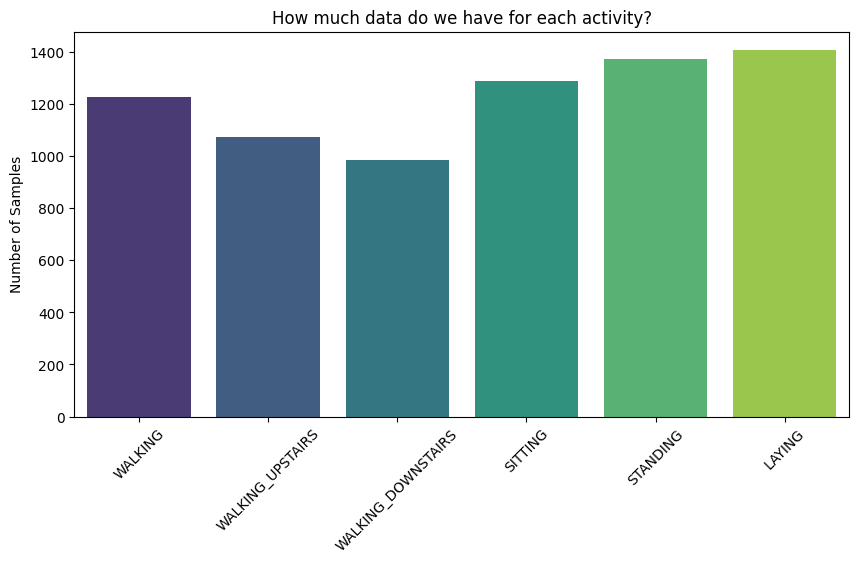

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
labels = pd.read_csv('UCI HAR Dataset/activity_labels.txt', sep=r'\s+', header=None, names=['ID', 'Name'])#activity names
activity_counts = y_train[0].value_counts().sort_index()#counting number of time activity occurs
activity_names = labels['Name'].values
plt.figure(figsize=(10, 5))#plot
sns.barplot(x=activity_names, y=activity_counts.values, palette='viridis')
plt.title('How much data do we have for each activity?')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.show()

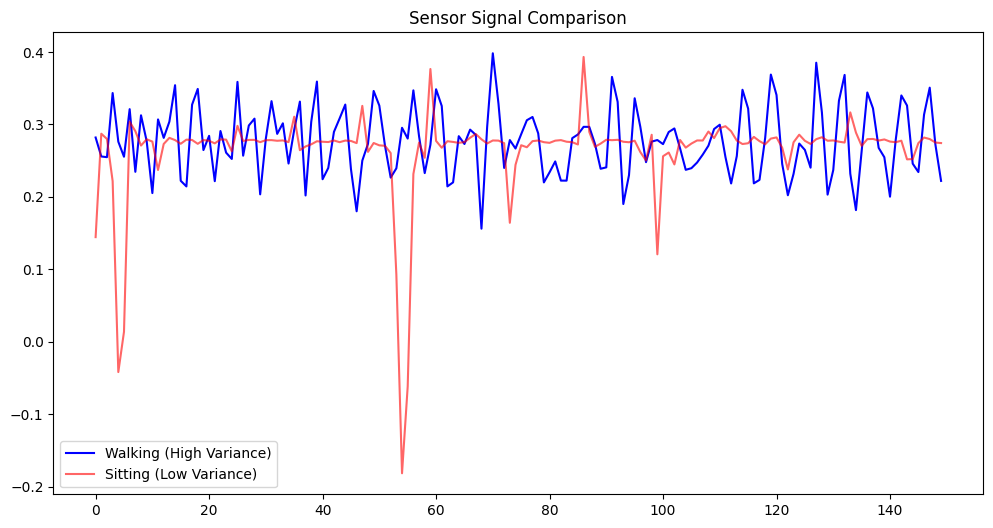

In [5]:
#'WALKING' vs 'SITTING'
plt.figure(figsize=(12,6))

X_train['ActivityName'] = X_train['Activity_ID'].map(activity_labels.set_index('ID')['Activity'])

walking = X_train[X_train['ActivityName'] == 'WALKING']['tBodyAcc-mean()-X'].iloc[:150]
sitting = X_train[X_train['ActivityName'] == 'SITTING']['tBodyAcc-mean()-X'].iloc[:150]

plt.plot(walking.values, label='Walking (High Variance)', color='blue')
plt.plot(sitting.values, label='Sitting (Low Variance)', color='red', alpha=0.6)

plt.title('Sensor Signal Comparison')
plt.legend()
plt.show()

In [6]:
%cd HAR-Machine-Learning
import pandas as pd

X_test = pd.read_csv('UCI HAR Dataset/test/X_test.txt', sep=r'\s+', header=None)#test signals
y_test = pd.read_csv('UCI HAR Dataset/test/y_test.txt', sep=r'\s+', header=None) #test activityIDs
X_test.columns = features['Sensor_Feature']
print(f"Test Data Loaded! Shape: {X_test.shape}")

[Errno 2] No such file or directory: 'HAR-Machine-Learning'
/content/HAR-Machine-Learning
Test Data Loaded! Shape: (2947, 561)


In [7]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42) #initializing with 100 desicion trees
print("Training the Baseline Model..")
# Drop 'Activity_ID' and 'ActivityName' from X_train features as they are not input features for the model
rf_model.fit(X_train.drop(columns=['Activity_ID', 'ActivityName'], errors='ignore'), y_train[0])

print("Training Complete!")

Training the Baseline Model..
Training Complete!


In [8]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = rf_model.predict(X_test) #prediction
accuracy = accuracy_score(y_test, y_pred) #accuracy
print(f"Baseline Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=activity_labels['Activity']))

Baseline Accuracy: 92.57%

Detailed Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.89      0.97      0.93       496
  WALKING_UPSTAIRS       0.88      0.89      0.89       471
WALKING_DOWNSTAIRS       0.97      0.86      0.91       420
           SITTING       0.91      0.90      0.90       491
          STANDING       0.91      0.92      0.91       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.93      0.93      2947



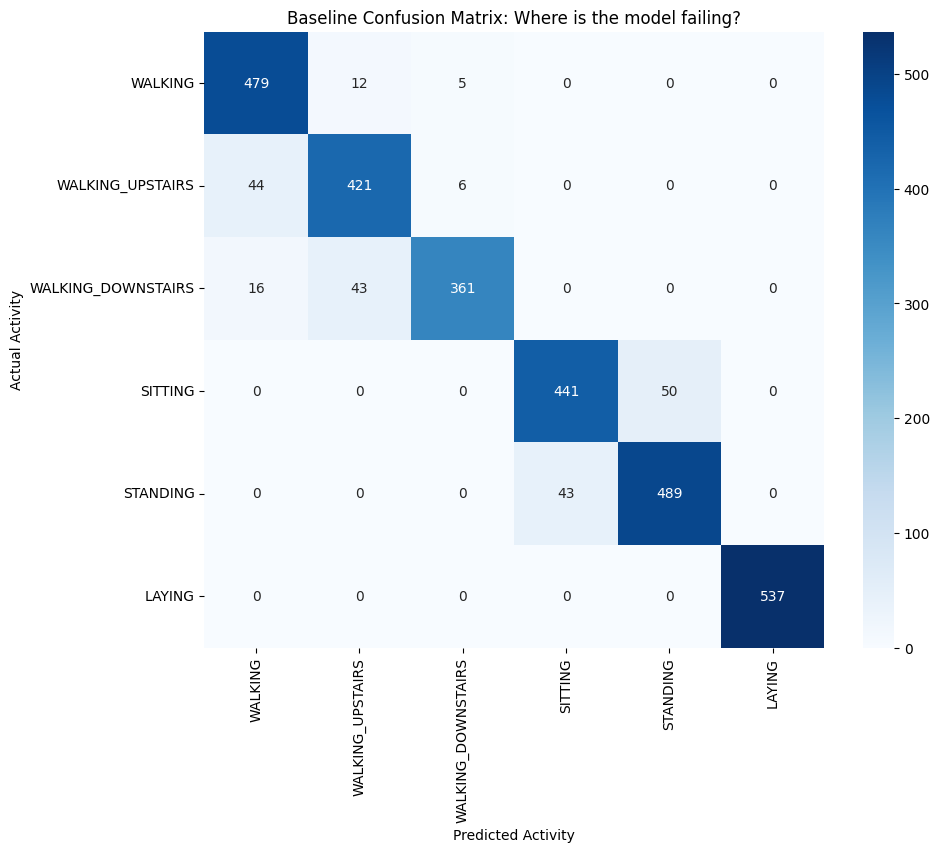

In [9]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=activity_labels['Activity'],
            yticklabels=activity_labels['Activity'])

plt.title('Baseline Confusion Matrix: Where is the model failing?')
plt.xlabel('Predicted Activity')
plt.ylabel('Actual Activity')
plt.show()

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split

print("Preparing Data for PyTorch...")
# 1. Clean the data (remove the text columns Shakshitha added for EDA)
X_train_clean = X_train.drop(columns=['Activity_ID', 'ActivityName'], errors='ignore')
X_test_clean = X_test.drop(columns=['Activity_ID', 'ActivityName'], errors='ignore')

# 2. PyTorch needs labels to start at 0, but UCI dataset starts at 1. We subtract 1.
y_train_num = y_train[0].values - 1
y_test_num = y_test[0].values - 1

# 3. Convert to PyTorch Tensors
X_tensor = torch.tensor(X_train_clean.values, dtype=torch.float32)
y_tensor = torch.tensor(y_train_num, dtype=torch.long)
X_test_tensor = torch.tensor(X_test_clean.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_num, dtype=torch.long)

# 4. Create DataLoader
train_dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# 5. Define Your Winning Architecture
class HAR_NeuralNet(nn.Module):
    def __init__(self):
        super(HAR_NeuralNet, self).__init__()
        self.layer1 = nn.Linear(561, 256)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(256, 128)
        self.dropout = nn.Dropout(0.3)
        self.layer3 = nn.Linear(128, 6)

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.dropout(x)
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

pytorch_model = HAR_NeuralNet()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pytorch_model.parameters(), lr=0.001)

# 6. Train the Model
print("Training PyTorch Neural Network...")
epochs = 50
for epoch in range(epochs):
    pytorch_model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = pytorch_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

print("PyTorch Training Complete!")

Preparing Data for PyTorch...
Training PyTorch Neural Network...
PyTorch Training Complete!



🏆 Utsav's PyTorch Neural Network Accuracy: 95.42%



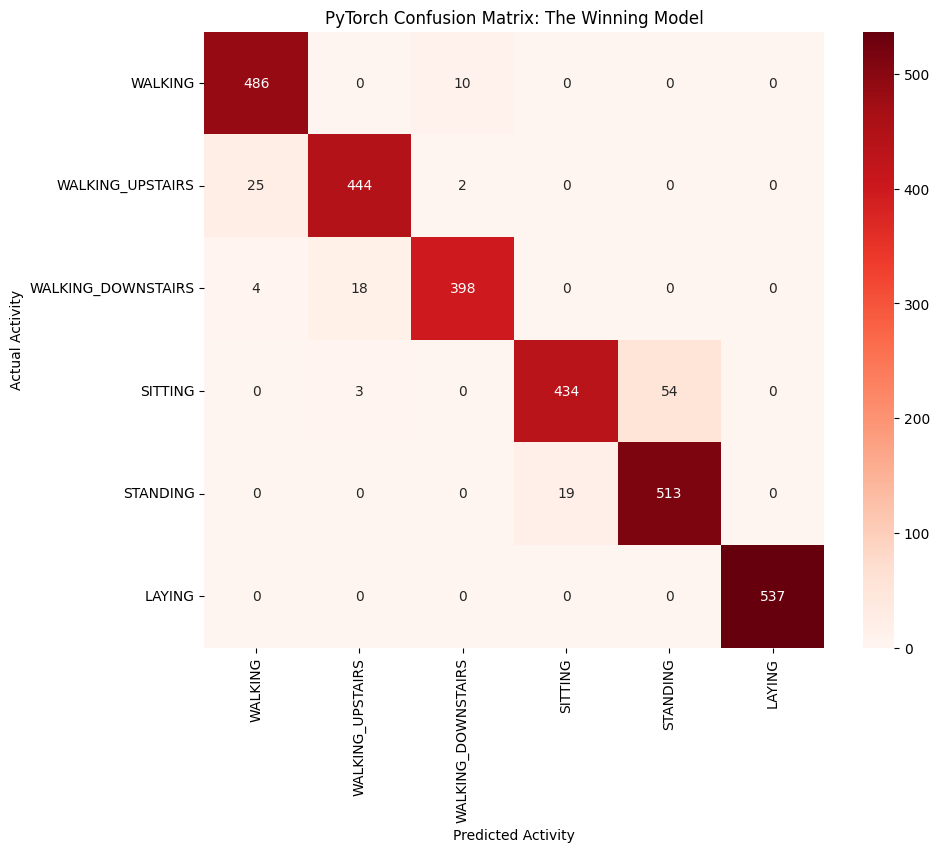

In [11]:
# Evaluate Your PyTorch Model
pytorch_model.eval()
with torch.no_grad():
    raw_predictions = pytorch_model(X_test_tensor)
    _, final_predictions = torch.max(raw_predictions, 1)

nn_accuracy = accuracy_score(y_test_num, final_predictions.numpy())
print(f"\n🏆 Utsav's PyTorch Neural Network Accuracy: {nn_accuracy * 100:.2f}%\n")

# Your PyTorch Confusion Matrix
plt.figure(figsize=(10, 8))
cm_nn = confusion_matrix(y_test_num, final_predictions.numpy())
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Reds',
            xticklabels=activity_labels['Activity'],
            yticklabels=activity_labels['Activity'])

plt.title('PyTorch Confusion Matrix: The Winning Model')
plt.xlabel('Predicted Activity')
plt.ylabel('Actual Activity')
plt.show()